# Infrared Solar Modules: Fault vs Normal CNN with 2-Class Softmax (TensorFlow/Keras)

**Nguyen Sy Hung (ID: 25MSA33055), 2026**

Machine Learning 1, MLE501.22, FSB

This notebook builds a **2-class categorical classifier** on the **Infrared Solar Modules** dataset by collapsing the original classes into:

- **normal** = `No-Anomaly`
- **fault** = every other original anomaly class

The goal is to keep the model **small, fast, and practical** while also returning an explicit **softmax probability distribution** such as:

- `fault = 0.80`
- `normal = 0.20`

That means this notebook uses a **2-unit softmax output** instead of a single-logit binary head.

## Model Architecture

```text
Input
Conv(32) -> BN -> ReLU -> MaxPool
Conv(64) -> BN -> ReLU -> MaxPool
Conv(96) -> BN -> ReLU -> MaxPool
GAP
Dense(32) -> ReLU
Dropout(0.2)
Dense(2) -> Softmax
```

## Notebook flow

1. Load the dataset from `module_metadata.json`
2. Run very light EDA
3. Preprocess images and collapse labels to 2 classes
4. Split into train / validation / test
5. Train a compact CNN with **2-class softmax**
6. Inspect predicted probabilities
7. Evaluate on the test set


In [2]:

# If needed on a fresh environment, uncomment:
# !pip install -q tensorflow scikit-learn pandas pillow matplotlib seaborn


In [3]:
import os
import json
import random
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

os.environ["ONEDNN_VERBOSE"] = "none"
os.environ["DNNL_VERBOSE"] = "0"
warnings.filterwarnings("ignore", category=UserWarning)

print("TensorFlow version:", tf.__version__)

2026-03-15 08:50:44.503459: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 08:50:44.811867: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 08:50:44.812130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 08:50:44.845350: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 08:50:44.971993: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.1


## Configuration

Set `DATASET_DIR` to the root folder of the extracted **Infrared Solar Modules** dataset.

This notebook is aligned to the dataset format defined by **`module_metadata.json`**:

```text
DATASET_DIR/
    module_metadata.json
    images/
        0.jpg
        1.jpg
        2.jpg
        ...
```

Each metadata entry contains at least:

- `image_filepath`
- `anomaly_class`

The binary experiment is then built by mapping:

- `No-Anomaly` -> `normal`
- everything else -> `fault`


In [ ]:
# Configuration
DATASET_DIR = Path("/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/dataset/2020-02-14_InfraredSolarModules/InfraredSolarModules") 
MODULE_METADATA_PATH = DATASET_DIR / "module_metadata.json"

IMG_HEIGHT = 24
IMG_WIDTH = 40
CHANNELS = 1

BATCH_SIZE = 64
EPOCHS = 10
SEED = 36

CLASS_NAMES = ["normal", "fault"]   # label 0 = normal, label 1 = fault
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NORMAL_CLASS_NAMES = {
    "no-anomaly", "no_anomaly", "no anomaly", "normal", "noanomaly"
}

# Run artifacts
MODELS_PARENT_DIR = Path("/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models")
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_PARENT_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_fault_vs_normal_softmax_cnn.keras"
FINAL_MODEL_PATH = RUN_DIR / "fault_vs_normal_softmax_cnn_final.keras"
HISTORY_CSV_PATH = RUN_DIR / "history.csv"
TRAINING_CURVES_PATH = RUN_DIR / "training_curves.png"
VAL_PREVIEW_PATH = RUN_DIR / "validation_predictions.csv"
TEST_PREVIEW_PATH = RUN_DIR / "test_predictions.csv"
METRICS_JSON_PATH = RUN_DIR / "metrics_summary.json"
CONFUSION_MATRIX_PATH = RUN_DIR / "test_confusion_matrix.png"

print(f"Run ID      : {RUN_ID}")
print(f"Artifacts   : {RUN_DIR.resolve()}")

# Runtime device selection
# Mirrors the XPU/GPU/CPU runtime logic used in logmel_cnn_v2_2.py
def _best_effort_set_memory_growth(tf_module, device_type: str):
    devices = tf_module.config.list_physical_devices(device_type)
    for device in devices:
        try:
            tf_module.config.experimental.set_memory_growth(device, True)
        except Exception:
            pass
    return devices

def _smoke_test_matmul(tf_module, device: str, n: int = 512):
    try:
        with tf.device(device):
            a = tf_module.random.normal([n, n])
            b = tf_module.random.normal([n, n])
            c = tf_module.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as exc:
        return False, repr(exc)

def configure_runtime_device(tf_module):
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf_module.__version__}")

    try:
        gpus = _best_effort_set_memory_growth(tf_module, "GPU")
    except Exception:
        gpus = []

    if gpus:
        ok, info = _smoke_test_matmul(tf_module, "/GPU:0")
        if ok:
            return "/GPU:0", "cuda", [d.name for d in gpus], info
        print("CUDA present but failed smoke test ->", info)

    try:
        import importlib
        importlib.import_module("intel_extension_for_tensorflow")
        xpus = _best_effort_set_memory_growth(tf_module, "XPU")
    except Exception as exc:
        xpus = []
        print("ITEX/XPU not available:", repr(exc))

    if xpus:
        ok, info = _smoke_test_matmul(tf_module, "/XPU:0")
        if ok:
            return "/XPU:0", "xpu", [d.name for d in xpus], info
        print("XPU present but failed smoke test ->", info)

    return "/CPU:0", "cpu", [], "ok"

RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)
print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
print(f"Devices    : {ACCEL_NAMES if ACCEL_NAMES else 'none detected -> CPU fallback'}")
print(f"Smoke test : {SMOKE_INFO}")


Run ID      : 20260315-085150
Artifacts   : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150
Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1


2026-03-15 08:51:54.986520: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok


In [5]:
def normalize_class_name(name: str) -> str:
    return name.strip().lower().replace("_", "-")

def binary_label_from_class(original_class: str) -> int:
    norm = normalize_class_name(original_class)
    return 0 if norm in NORMAL_CLASS_NAMES else 1  # 0 = normal, 1 = fault

def load_dataset_from_metadata(dataset_dir: Path, metadata_path: Path) -> pd.DataFrame:
    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"DATASET_DIR does not exist: {dataset_dir}\n"
            "Update DATASET_DIR to the extracted dataset folder."
        )
    if not metadata_path.exists():
        raise FileNotFoundError(
            f"module_metadata.json not found: {metadata_path}\n"
            "This notebook expects the RaptorMaps-style metadata file."
        )

    payload = json.loads(metadata_path.read_text(encoding="utf-8"))
    rows = []

    for module_id, record in payload.items():
        rel_path = record.get("image_filepath")
        original_class = record.get("anomaly_class")

        if rel_path is None or original_class is None:
            continue

        abs_path = dataset_dir / rel_path
        if not abs_path.exists():
            continue

        binary_label = binary_label_from_class(original_class)
        rows.append(
            {
                "module_id": str(module_id),
                "filepath": str(abs_path),
                "relative_filepath": rel_path,
                "original_class": original_class,
                "binary_label": binary_label,
                "binary_class": CLASS_NAMES[binary_label],
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No valid image rows could be built from module_metadata.json.")
    return df

df = load_dataset_from_metadata(DATASET_DIR, MODULE_METADATA_PATH)
df.head()


,module_id,filepath,relative_filepath,original_class,binary_label,binary_class
0,13357,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/13357.jpg,No-Anomaly,0,normal
1,13356,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/13356.jpg,No-Anomaly,0,normal
2,19719,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/19719.jpg,No-Anomaly,0,normal
3,11542,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/11542.jpg,No-Anomaly,0,normal
4,11543,/mnt/d/mse/nguyen_sy_hung_codebases/machine-le...,images/11543.jpg,No-Anomaly,0,normal


## Quick EDA

In [6]:
# Basic dataset metrics
n_images = len(df)
n_original_classes = df["original_class"].nunique()
binary_counts = df["binary_class"].value_counts().reindex(CLASS_NAMES, fill_value=0)
original_counts = df["original_class"].value_counts().sort_values(ascending=False)

# Read image sizes (core metric only)
sizes = []
for fp in df["filepath"]:
    with Image.open(fp) as im:
        sizes.append(im.size)  # (width, height)

size_series = pd.Series(sizes)
unique_sizes = size_series.value_counts()

print(f"Total images         : {n_images:,}")
print(f"Original class count : {n_original_classes}")
print("Binary class counts  :")
display(binary_counts.to_frame("count"))
print("Most common image sizes (width, height):")
display(unique_sizes.head(10).rename("count").to_frame())


Total images         : 20,000
Original class count : 12
Binary class counts  :


,count
binary_class,
normal,10000
fault,10000


Most common image sizes (width, height):


,count
"(24, 40)",20000


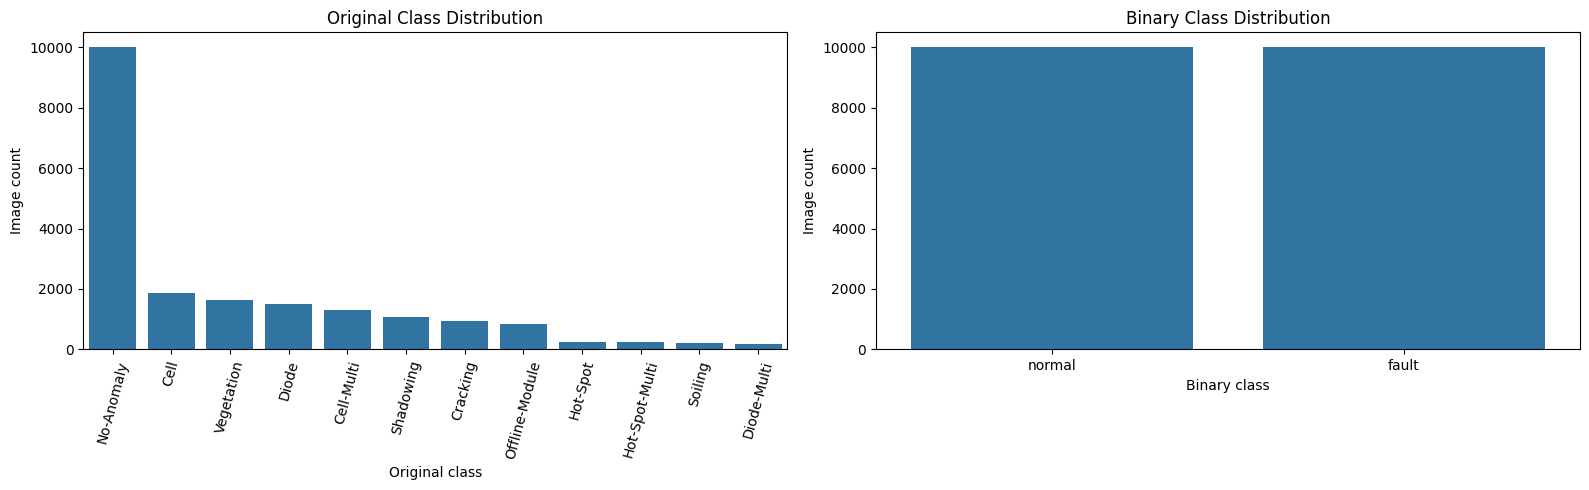

In [7]:

 # EDA Plot 1: original class distribution + binary class distribution
_, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    x=original_counts.index,
    y=original_counts.values,
    ax=axes[0],
)
axes[0].set_title("Original Class Distribution")
axes[0].set_xlabel("Original class")
axes[0].set_ylabel("Image count")
axes[0].tick_params(axis="x", rotation=75)

sns.barplot(
    x=binary_counts.index,
    y=binary_counts.values,
    ax=axes[1],
)
axes[1].set_title("Binary Class Distribution")
axes[1].set_xlabel("Binary class")
axes[1].set_ylabel("Image count")

plt.tight_layout()
plt.show()


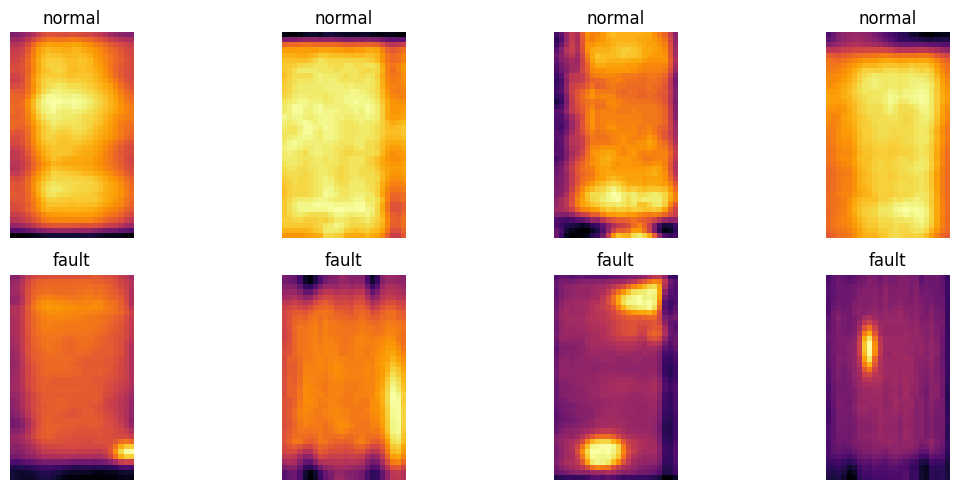

In [8]:

# EDA Plot 2: a few sample thermal images
def show_random_samples(dataframe, n_per_class=4):
    classes = ["normal", "fault"]
    _, axes = plt.subplots(len(classes), n_per_class, figsize=(3*n_per_class, 5))

    if len(classes) == 1:
        axes = np.array([axes])

    for row_idx, cls in enumerate(classes):
        subset = dataframe[dataframe["binary_class"] == cls].sample(
            n=min(n_per_class, len(dataframe[dataframe["binary_class"] == cls])),
            random_state=SEED
        )

        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            if col_idx < len(subset):
                img_path = subset.iloc[col_idx]["filepath"]
                with Image.open(img_path) as im:
                    ax.imshow(np.array(im), cmap="inferno")
                ax.set_title(cls)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(df)


## Split the data

We use a **stratified** split so the dataset remains stable across train, validation, and test.

To better preserve the underlying source distribution, the split is stratified by the **original anomaly class** first, not only by the collapsed binary label.

- Train: 70%
- Validation: 15%
- Test: 15%


In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["original_class"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["original_class"],
    random_state=SEED,
)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["binary_class"].value_counts(normalize=True).reindex(CLASS_NAMES, fill_value=0)
    print(f"\n{name} binary ratio:")
    print(counts)


Train size: 14000
Val size  : 3000
Test size : 3000

train binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64

val binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64

test binary ratio:
binary_class
normal    0.5
fault     0.5
Name: proportion, dtype: float64


## Preprocessing and augmentation

### Preprocessing
- load as grayscale
- resize to `(24, 40)`
- convert to float
- scale pixels to `[0, 1]`

### Labels
We keep integer labels:

- `0 = normal`
- `1 = fault`

The model then learns a **2-class softmax** over these two categories.

### Training augmentation
- left-right flip
- up-down flip
- slight brightness jitter

These are intentionally **light**. Thermal images are not the place for aggressive visual circus tricks.


### XPU training fix for augmentation

The original notebook used Keras preprocessing layers such as `RandomFlip` and `RandomBrightness`.
On Intel XPU via ITEX, those layers may trigger a runtime error:

`Unsupported algorithm id: 3`

That failure comes from the **stateful random-number generator path** used by those layers, not from `model.fit` itself.

This notebook version fixes the problem by:

- moving augmentation into the `tf.data` pipeline
- using `tf.image.stateless_random_*` ops
- forcing the augmentation function onto **CPU**
- keeping the **model training itself** on the selected runtime device (`XPU`, `GPU`, or `CPU`)

So the cheap random augmentation stays on CPU, while the actual neural network still uses the accelerator.


In [10]:

def decode_resize_normalize(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)

# ------------------------------------------------------------------
# XPU-safe augmentation
# ------------------------------------------------------------------
# Why not use keras.layers.RandomFlip / RandomBrightness here?
# On Intel XPU with ITEX, those layers can emit stateful RNG ops that
# fail at runtime with:
#   "Unsupported algorithm id: 3"
# So we move augmentation into tf.data and force it onto CPU using
# stateless random ops. The model can still train on XPU; only the
# lightweight augmentation runs on CPU.
#
# If you want the absolute simplest fallback, set ENABLE_AUGMENTATION=False.
# ------------------------------------------------------------------
ENABLE_AUGMENTATION = True

def augment_on_cpu_stateless(image, label):
    with tf.device("/CPU:0"):
        seed = tf.random.uniform(
            shape=[2],
            minval=0,
            maxval=2**31 - 1,
            dtype=tf.int32,
        )

        image = tf.image.stateless_random_flip_left_right(image, seed=seed)

        seed = tf.random.uniform(
            shape=[2],
            minval=0,
            maxval=2**31 - 1,
            dtype=tf.int32,
        )
        image = tf.image.stateless_random_flip_up_down(image, seed=seed)

        seed = tf.random.uniform(
            shape=[2],
            minval=0,
            maxval=2**31 - 1,
            dtype=tf.int32,
        )
        # brightness jitter on CPU, clipped back to [0, 1]
        image = tf.image.stateless_random_brightness(image, max_delta=0.08, seed=seed)
        image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["filepath"].values, dataframe["binary_label"].values.astype("int32"))
    )
    ds = ds.map(decode_resize_normalize, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        if ENABLE_AUGMENTATION:
            ds = ds.map(augment_on_cpu_stateless, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)


## Build the compact CNN

The convolutional backbone stays compact, but the output head is now:

- `Dense(2, activation="softmax")`

This makes the model return an explicit categorical distribution:

- `P(normal | image)`
- `P(fault | image)`


In [11]:
def conv_bn_relu(x, filters, kernel_size=3):
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = conv_bn_relu(inputs, 32)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 64)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = conv_bn_relu(x, 96)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probs")(x)

    model = keras.Model(inputs, outputs, name="fault_vs_normal_softmax_cnn")
    return model

with tf.device(RUNTIME_DEVICE):
    model = build_model()
model.summary()


Model: "fault_vs_normal_softmax_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 24, 40, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 24, 40, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 24, 40, 32)        128       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 24, 40, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 20, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 12,

## Compile and train

Training setup:
- **Optimizer**: AdamW
- **Loss**: Sparse categorical cross-entropy
- **Monitored validation metric**: validation accuracy
- **Early stopping**: restores the best weights

Because the output is now a **2-class softmax**, the loss switches from BCE-with-logits to **sparse categorical cross-entropy**.


In [12]:
optimizer = keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )

history_df = pd.DataFrame(history.history)
history_df.to_csv(HISTORY_CSV_PATH, index=False)

with tf.device(RUNTIME_DEVICE):
    model.save(str(FINAL_MODEL_PATH))

print(f"Saved best checkpoint : {BEST_MODEL_PATH}")
print(f"Saved final model     : {FINAL_MODEL_PATH}")
print(f"Saved history CSV     : {HISTORY_CSV_PATH}")

Epoch 1/3


2026-03-15 08:55:09.804398: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.
2026-03-15 08:55:20.346306: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3737 of 14000
2026-03-15 08:55:33.110783: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


438/438 [==============================] - ETA: 0s - loss: 0.5914 - accuracy: 0.6909
Epoch 1: val_accuracy improved from -inf to 0.53267, saving model to /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/best_fault_vs_normal_softmax_cnn.keras
438/438 [==============================] - 187s 337ms/step - loss: 0.5914 - accuracy: 0.6909 - val_loss: 0.9387 - val_accuracy: 0.5327
Epoch 2/3


2026-03-15 08:58:26.127931: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 8165 of 14000
2026-03-15 08:58:31.888528: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


438/438 [==============================] - ETA: 0s - loss: 0.5081 - accuracy: 0.7506
Epoch 2: val_accuracy improved from 0.53267 to 0.71233, saving model to /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/best_fault_vs_normal_softmax_cnn.keras
438/438 [==============================] - 116s 229ms/step - loss: 0.5081 - accuracy: 0.7506 - val_loss: 0.4962 - val_accuracy: 0.7123
Epoch 3/3


2026-03-15 09:00:22.385314: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5961 of 14000
2026-03-15 09:00:40.899479: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


438/438 [==============================] - ETA: 0s - loss: 0.4717 - accuracy: 0.7806
Epoch 3: val_accuracy did not improve from 0.71233
438/438 [==============================] - 196s 383ms/step - loss: 0.4717 - accuracy: 0.7806 - val_loss: 0.5979 - val_accuracy: 0.6820
Saved best checkpoint : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/best_fault_vs_normal_softmax_cnn.keras
Saved final model     : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/fault_vs_normal_softmax_cnn_final.keras
Saved history CSV     : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/history.csv


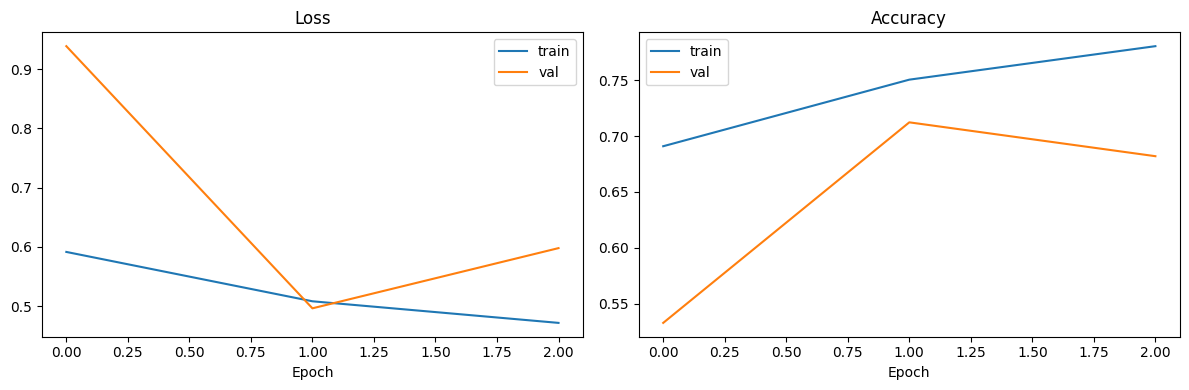

Saved training curves : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/training_curves.png


In [13]:
# Compact training curves
history_df = pd.DataFrame(history.history)

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["loss"], label="train")
axes[0].plot(history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="train")
axes[1].plot(history_df["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved training curves : {TRAINING_CURVES_PATH}")

## Inspect probability outputs

Since the model uses **softmax**, each prediction already contains a full 2-class probability distribution:

- `normal probability`
- `fault probability`

These two probabilities sum to 1.


In [14]:
def predict_probabilities(model, ds):
    probs = model.predict(ds, verbose=0)
    labels = np.concatenate([y.numpy().ravel() for _, y in ds], axis=0).astype(int)
    pred_idx = np.argmax(probs, axis=1)
    return labels, probs, pred_idx

y_val, p_val, y_val_pred = predict_probabilities(model, val_ds)

preview_df = pd.DataFrame(
    {
        "normal_probability": p_val[:, 0],
        "fault_probability": p_val[:, 1],
        "predicted_class": [CLASS_NAMES[i] for i in y_val_pred],
        "true_class": [CLASS_NAMES[i] for i in y_val],
    }
)
preview_df.to_csv(VAL_PREVIEW_PATH, index=False)

val_metrics = {
    "accuracy": float(accuracy_score(y_val, y_val_pred)),
    "precision": float(precision_score(y_val, y_val_pred, zero_division=0)),
    "recall": float(recall_score(y_val, y_val_pred, zero_division=0)),
    "f1": float(f1_score(y_val, y_val_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, p_val[:, 1])),
}

display(preview_df.head(10))

print("Validation Accuracy :", val_metrics["accuracy"])
print("Validation Precision:", val_metrics["precision"])
print("Validation Recall   :", val_metrics["recall"])
print("Validation F1       :", val_metrics["f1"])
print("Validation ROC-AUC  :", val_metrics["roc_auc"])
print(f"Saved validation predictions: {VAL_PREVIEW_PATH}")

,normal_probability,fault_probability,predicted_class,true_class
0,0.843238,0.156762,normal,normal
1,0.882651,0.117349,normal,normal
2,0.839107,0.160893,normal,normal
3,0.726328,0.273672,normal,normal
4,0.854025,0.145975,normal,normal
5,0.670460,0.329540,normal,fault
6,0.909688,0.090313,normal,normal
7,0.834417,0.165583,normal,normal
8,0.687133,0.312867,normal,fault
9,0.831068,0.168932,normal,normal


Validation Accuracy : 0.682
Validation Precision: 0.9292452830188679
Validation Recall   : 0.394
Validation F1       : 0.5533707865168539
Validation ROC-AUC  : 0.8109026666666668
Saved validation predictions: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/validation_predictions.csv


## Final evaluation on the test set


In [15]:
y_test, p_test, y_pred = predict_probabilities(model, test_ds)

test_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, p_test[:, 1])),
}

print("Test Accuracy :", test_metrics["accuracy"])
print("Test Precision:", test_metrics["precision"])
print("Test Recall   :", test_metrics["recall"])
print("Test F1       :", test_metrics["f1"])
print("Test ROC-AUC  :", test_metrics["roc_auc"])

print("\nClassification report:")
test_report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0)
print(test_report)

test_preview_df = pd.DataFrame(
    {
        "fault_probability": p_test[:, 1],
        "normal_probability": p_test[:, 0],
        "predicted_class": [CLASS_NAMES[i] for i in y_pred],
        "true_class": [CLASS_NAMES[i] for i in y_test],
    }
).sort_values("fault_probability", ascending=False)
test_preview_df.to_csv(TEST_PREVIEW_PATH, index=False)

metrics_payload = {
    "run_id": RUN_ID,
    "run_dir": str(RUN_DIR),
    "runtime_device": RUNTIME_DEVICE,
    "backend": BACKEND,
    "dataset_dir": str(DATASET_DIR),
    "best_model_path": str(BEST_MODEL_PATH),
    "final_model_path": str(FINAL_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "training_curves_path": str(TRAINING_CURVES_PATH),
    "validation_predictions_path": str(VAL_PREVIEW_PATH),
    "test_predictions_path": str(TEST_PREVIEW_PATH),
    "confusion_matrix_path": str(CONFUSION_MATRIX_PATH),
    "validation_metrics": val_metrics,
    "test_metrics": test_metrics,
    "classification_report": test_report,
}
METRICS_JSON_PATH.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")

display(test_preview_df.head(10))

print(f"Saved test predictions : {TEST_PREVIEW_PATH}")
print(f"Saved metrics summary  : {METRICS_JSON_PATH}")

Test Accuracy : 0.6726666666666666
Test Precision: 0.9085173501577287
Test Recall   : 0.384
Test F1       : 0.5398313027179007
Test ROC-AUC  : 0.8024097777777777

Classification report:
              precision    recall  f1-score   support

      normal       0.61      0.96      0.75      1500
       fault       0.91      0.38      0.54      1500

    accuracy                           0.67      3000
   macro avg       0.76      0.67      0.64      3000
weighted avg       0.76      0.67      0.64      3000



,fault_probability,normal_probability,predicted_class,true_class
2726,1.000000,6.330711e-09,fault,fault
105,1.000000,6.334286e-09,fault,fault
1694,1.000000,1.156383e-10,fault,fault
1236,1.000000,1.043189e-07,fault,fault
1318,1.000000,2.133706e-07,fault,fault
1788,0.999999,7.377815e-07,fault,fault
1032,0.999999,1.009857e-06,fault,fault
2156,0.999999,1.142514e-06,fault,fault
1092,0.999998,1.513790e-06,fault,fault
1728,0.999998,1.742980e-06,fault,fault


Saved test predictions : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/test_predictions.csv
Saved metrics summary  : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/classwork/solar/models/20260315-085150/metrics_summary.json


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix : {CONFUSION_MATRIX_PATH}")

In [ ]:
# Save the trained model 
# model.save("fault_vs_normal_cnn_final.keras")
